In [5]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing as sp
import pickle
import matplotlib.pyplot as plt
import scienceplots
import scipy
import os
import time
from datetime import date
from scipy.stats import ttest_ind
today = date.today()

from utils import readSingleCellData_sqlalch, handle_nans, extract_cpfeature_names,\
    find_correlation, check_feature_similarity_dendrogram, find_end_slope2, plot_lollipop_feature_corr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import seaborn as sns
print(sns.__version__)
import sklearn
print(sklearn.__version__)

0.12.2
1.0.2


In [47]:
ls /home/jupyter-mhaghigh@broadinst-ee45a/bucket/projects/2016_08_01_RadialMitochondriaDistribution_donna/workspace/singleCellData

aggregated_profiles_fibroblast.csv*
images.pkl*
images.rds*
single_cell_with_annot_allFeatures.pkl*
single_cell_with_annot_allFeatures.rds*
single_cell_with_annot.pkl*
single_cell_with_annot.rds*


## Read Data

In [60]:
%%time

home_path="/home/ubuntu/" # ec2
home_path="/home/jupyter-mhaghigh@broadinst-ee45a/" #dgx

rootDir=home_path+"bucket/projects/2016_08_01_RadialMitochondriaDistribution_donna/"

compartments = ['mito','actin','dna']
# the directory data and images are stored in
dataDir=rootDir+"workspace/singleCellData/"
imDir=rootDir+"Mito_Morphology_input/images/"
sql_data= rootDir+"workspace/backend/Mito_Morphology_input"

df_1_0_0=pd.read_pickle(dataDir+'single_cell_with_annot.pkl', compression='infer')
subject_list=os.listdir(sql_data)
sc_df_ls=[]
compartments = ["Cells","Cytoplasm","Nuclei"]
for si in subject_list:
    fileName = sql_data+'/'+si+'/'+si+'.sqlite'
    sc_df = readSingleCellData_sqlalch(fileName,compartments);
    sc_df['subject']=si
    sc_df_ls.append(sc_df)

df_new = pd.concat(sc_df_ls,ignore_index=True)

df_1_0=pd.read_pickle(dataDir+'single_cell_with_annot_allFeatures.pkl', compression='infer')
df_1_0 = df_1_0.interpolate()

common_subjects = list(set(df_new['subject'].unique()) & set(df_1_0['subject'].unique()))
df_1 = df_new[df_new['subject'].isin(common_subjects)]


df_1 = pd.merge(df_1, df_1_0[['subject','label']].drop_duplicates(), on='subject',how='left')
disease_labels=pd.read_excel(home_path+"bucket/projects/2016_08_01_RadialMitochondriaDistribution_donna/\
workspace/metadata/patient_labels_updatedSept302025.xlsx")
disease_labels=disease_labels.rename(columns={"ID": "subject"})
disease_labels["subject"]=disease_labels["subject"].astype(str)

df_1 = pd.merge(df_1,disease_labels,on=["subject"],how="left")

df_1['subject'] = df_1['subject'].replace(['370E','370F','370H'],'370');

df_1.loc[df_1['subject']=='272','label']='Control'
df_1.loc[df_1['subject']=='MCL004','label']='SZA'

##################### Clean and shrink features
(
    cp_features,
    cp_features_analysis_0,
) = extract_cpfeature_names(df_1)
df_1, cp_features_analysis = handle_nans(
    df_1,
    cp_features_analysis_0,
    thrsh_null_ratio=0.05,
    thrsh_std=0.001,
    fill_na_method="drop-rows",
)
    

############### remove cells on the border
borderLength=200

im_width = df_1['Width_Mito'].values[0] #1388
im_height = df_1['Height_Mito'].values[0] #1040
print(df_1.shape)
df_1_centCells=df_1.loc[~((df_1['Nuclei_Location_Center_X']>(im_width-borderLength)) | (df_1['Nuclei_Location_Center_X']<(borderLength))\
                        | (df_1['Nuclei_Location_Center_Y']>(im_height-borderLength)) | (df_1['Nuclei_Location_Center_Y']<(borderLength))),:].reset_index(drop=True)

print("After border cell removal: ",df_1_centCells.shape)

df_1_centCells['Cells2Nuclei_MajorAxisLengthRatio']=df_1_centCells['Cells_AreaShape_MajorAxisLength']/df_1_centCells['Nuclei_AreaShape_MajorAxisLength']
df_1_centCells['Cells2Nuclei_AreaShapeRatio']=df_1_centCells['Cells_AreaShape_Area']/df_1_centCells['Nuclei_AreaShape_Area']
df_1_centCells = df_1_centCells[df_1_centCells['Cells2Nuclei_MajorAxisLengthRatio']>2].reset_index(drop=True)
df_1_centCells = df_1_centCells[df_1_centCells['Cells2Nuclei_AreaShapeRatio']>5].reset_index(drop=True)

print("After cell seg pron cells removal: ",df_1_centCells.shape)

df_1= df_1_centCells[(df_1_centCells['Cells_Intensity_MeanIntensity_Actin']<.5) &\
                                (df_1_centCells['Nuclei_Intensity_MeanIntensity_Actin']<.55)].reset_index(drop=True)

print("After intensity artifact cells removal: ",df_1.shape)


df_1, cp_features_analysis = handle_nans(
    df_1,
    cp_features_analysis,
    thrsh_null_ratio=0.05,
    thrsh_std=0.001,
    fill_na_method="drop-rows",
)


scaler = sp.StandardScaler()
s0=scaler.fit(df_1[cp_features_analysis])
df_1['label'] = df_1['label'].replace('MDD or Dep','MDD')
df_1_scaled=df_1.copy()

df_1_scaled[cp_features_analysis]=s0.transform(df_1[cp_features_analysis])


pat='CEN';ring='12';f_substr='MeanFrac';
target_columns=["Cells_RadialDistribution_"+f_substr+"_mito_tubeness_"+pat+"_"+str(i)+"of"+ring \
                            for i in range(int(ring)-11,int(ring)+1)]

df_1_avg_persub=df_1_scaled.groupby(["subject","label"])[cp_features_analysis].mean().reset_index()
ctrl=df_1_avg_persub[df_1_avg_persub['label']=='Control'][target_columns]

df_1_avg_persub[target_columns]=df_1_avg_persub[target_columns]-ctrl.mean()


df_1_avg_persub[["peak","slope"]] = df_1_avg_persub.apply(lambda x: find_end_slope2(x[target_columns]\
                                        ,plot=False,subject=x['subject'],smooth=True), axis=1,result_type='expand')
         
if 0:
    df_1_avg_persub.to_csv(dataDir+'/aggregated_profiles_fibroblast.csv',index=False)

similar_fs_2remove=find_correlation(df_1_scaled[cp_features_analysis],\
                                                 threshold=0.7,remove_negative=True)

cp_features_collcorr=list(set(cp_features_analysis) - set(similar_fs_2remove))

# df_1['label'] = df_1['label'].replace('MDD or Dep','MDD')
# df_1_scaled['label'] = df_1_scaled['label'].replace('MDD or Dep','MDD')

cp_features: 2185
cols2remove_manyNulls []
cols2remove_lowVars ['Cytoplasm_Texture_DifferenceVariance_Mito_10_01_256', 'Nuclei_Texture_DifferenceVariance_Mito_5_02_256', 'Cells_Texture_DifferenceVariance_Actin_10_02_256', 'Nuclei_Texture_DifferenceVariance_DNA_3_02_256', 'Nuclei_Texture_DifferenceVariance_Mito_3_02_256', 'Nuclei_Texture_DifferenceVariance_Mito_5_00_256', 'Nuclei_Texture_DifferenceVariance_Actin_5_03_256', 'Nuclei_Texture_DifferenceVariance_Actin_10_00_256', 'Cells_Texture_DifferenceVariance_Mito_3_01_256', 'Nuclei_Texture_DifferenceVariance_DNA_10_03_256', 'Cytoplasm_Texture_DifferenceVariance_Mito_10_00_256', 'Cytoplasm_Texture_DifferenceVariance_Mito_3_03_256', 'Cytoplasm_Texture_DifferenceVariance_Actin_3_02_256', 'Cytoplasm_Texture_DifferenceVariance_Mito_3_02_256', 'Cytoplasm_Texture_DifferenceVariance_Actin_3_00_256', 'Nuclei_Texture_DifferenceVariance_DNA_10_02_256', 'Nuclei_Texture_DifferenceVariance_Mito_3_01_256', 'Cells_Texture_DifferenceVariance_Actin_10_01

In [59]:
disease_labels

,subject,D,D1,D2,D3,Sex,Age
0,5,BP,BP,NaN,NaN,M,47
1,8,BPII,BPII,NaN,NaN,M,54
2,12,BP,BP,NaN,NaN,F,35
3,16,BP,BP,NaN,NaN,M,19
4,23,BP,BP,NaN,NaN,F,43
...,...,...,...,...,...,...,...
177,MLF002,MDD w psychosis,MDD,psychosis,NaN,F,27
178,370E,Control,Control,NaN,NaN,F,52
179,370F,Control,Control,NaN,NaN,F,52
180,370G,Control,Control,NaN,NaN,F,52


In [71]:
# df_1_avg_persub[['subject','label']].to_csv('subjects.csv',index=False)
df_1_scaled[df_1_scaled['subject']=='272'][['label','D']]

,label,D
16732,Control,"SZA, bipolar type"
16733,Control,"SZA, bipolar type"
16734,Control,"SZA, bipolar type"
16735,Control,"SZA, bipolar type"
16736,Control,"SZA, bipolar type"
...,...,...
16938,Control,"SZA, bipolar type"
16939,Control,"SZA, bipolar type"
16940,Control,"SZA, bipolar type"
16941,Control,"SZA, bipolar type"


In [54]:
df_1_avg_persub[['subject','label']]

,subject,label
0,100,SZ
1,102,BP
2,103,SZ
3,104,BP
4,107,BP
...,...,...
163,MCL128,BP
164,MCL139,Control
165,MCL162,Control
166,MCL168,Control


In [28]:
[f for f in cp_features_analysis if 'Cells_AreaShape_' in f]

['Cells_AreaShape_EquivalentDiameter',
 'Cells_AreaShape_Solidity',
 'Cells_AreaShape_MinFeretDiameter',
 'Cells_AreaShape_Compactness',
 'Cells_AreaShape_Eccentricity',
 'Cells_AreaShape_Perimeter',
 'Cells_AreaShape_Orientation',
 'Cells_AreaShape_MeanRadius',
 'Cells_AreaShape_MaximumRadius',
 'Cells_AreaShape_EulerNumber',
 'Cells_AreaShape_MaxFeretDiameter',
 'Cells_AreaShape_MinorAxisLength',
 'Cells_AreaShape_Extent',
 'Cells_AreaShape_MajorAxisLength',
 'Cells_AreaShape_MedianRadius',
 'Cells_AreaShape_FormFactor',
 'Cells_AreaShape_BoundingBoxArea',
 'Cells_AreaShape_Area',
 'Cells_AreaShape_ConvexArea']

In [3]:
# df_1_avg_persub.apply(lambda x: find_end_slope2(x[target_columns]\
#                                         ,plot=False,subject=x['subject'],smooth=True), axis=1,result_type='expand')

In [6]:
# df_1.columns

In [63]:
# df_1_scaled.head()
# df_1.loc[df_1['label'].isin('Control'),'subject']

from typing import Optional
import matplotlib.pyplot as plt

def plot_lollipop_feature_corr(
    df: pd.DataFrame,
    target_feature: str,
    method: str = "spearman",
    top_n: Optional[int] = None,
    abs_corr: bool = False,
    ax: Optional[plt.Axes] = None,
):
    """
    Plot a lollipop chart of correlation between a target feature and all other features.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with all features (columns).
    target_feature : str
        Name of the feature to correlate against all others.
    method : {"spearman", "pearson"}, default "spearman"
        Correlation method.
    top_n : int or None, default None
        If given, plot only the top_n features by |correlation|.
    abs_corr : bool, default False
        If True, sort by absolute correlation (magnitude), but keep sign on the axis.
    ax : matplotlib.axes.Axes or None, default None
        Existing axis to plot on. If None, a new figure and axis are created.
    """

    if target_feature not in df.columns:
        raise ValueError(f"{target_feature!r} not found in DataFrame columns.")

    # Compute correlations for the target feature
    corr = df.corr(method=method)[target_feature].drop(target_feature)

    # Decide sorting key
    sort_values = corr.abs() if abs_corr else corr
    corr_sorted = corr.loc[sort_values.sort_values(ascending=True).index]

    # Optionally keep only top_n by absolute magnitude
    if top_n is not None:
        corr_sorted = corr_sorted.iloc[-top_n:]  # highest correlations

    # Create axis if needed
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, max(4, len(corr_sorted) * 0.25)))
        created_fig = True

    # Positions and values
    y_pos = range(len(corr_sorted))
    x_vals = corr_sorted.values
    labels = corr_sorted.index

    # Draw stems (lines) and heads (dots)
    ax.hlines(y=y_pos, xmin=0, xmax=x_vals)  # stems
    ax.scatter(x_vals, y_pos)                # heads

    # Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel(f"{method.capitalize()} correlation with {target_feature}")
    ax.set_title(f"Lollipop plot of correlations with {target_feature}")
    ax.axvline(0, linestyle="--", linewidth=1)  # reference line at 0
    ax.margins(x=0.05)

    plt.tight_layout()
    if created_fig:
        plt.show()

    return ax


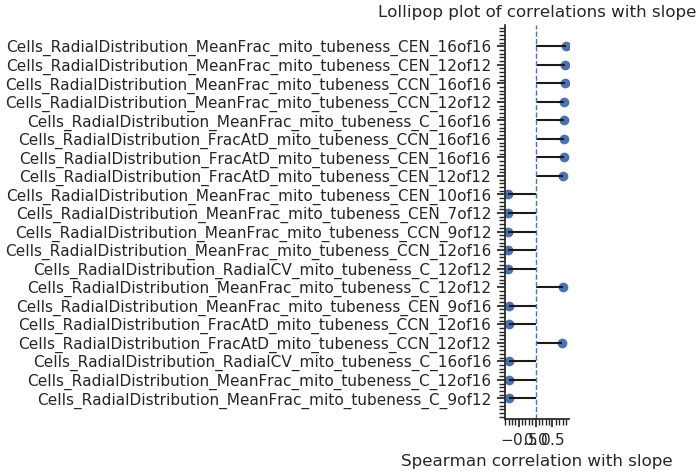

In [64]:
plot_lollipop_feature_corr(df_1_avg_persub, "slope", method="spearman", top_n=20, abs_corr=True)

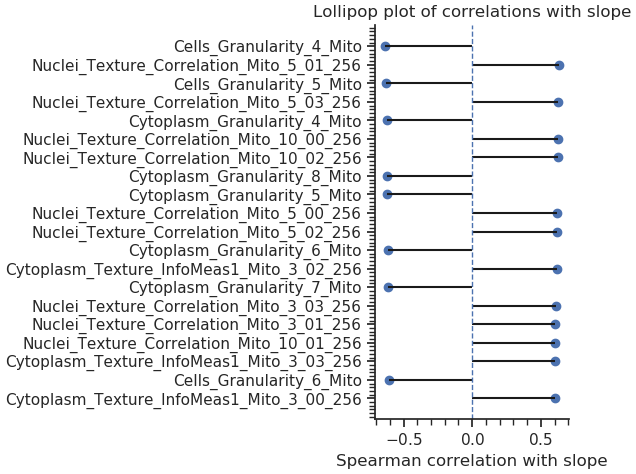

In [65]:
plot_lollipop_feature_corr(df_1_avg_persub[[c for c in df_1_avg_persub.columns if \
                    'mito_tubeness' not in c]], "slope", method="spearman", top_n=20, abs_corr=True)

In [12]:
df_1_avg_persub

,subject,label,Cells_RadialDistribution_RadialCV_mito_tubeness_CEN_5of16,Nuclei_Texture_Correlation_DNA_10_00_256,Cells_Texture_Contrast_Actin_3_01_256,Cytoplasm_Intensity_MinIntensity_DNA,Nuclei_Texture_SumVariance_Mito_10_03_256,Cytoplasm_Intensity_MaxIntensity_DNA,Cytoplasm_Texture_SumVariance_Mito_5_00_256,Cells_Texture_InfoMeas1_Mito_3_02_256,...,Cells_Intensity_MinIntensityEdge_Mito,Cells_Texture_SumAverage_Mito_3_00_256,Nuclei_Texture_Entropy_Actin_5_01_256,Cells_Texture_DifferenceVariance_DNA_3_00_256,Cells_Texture_Contrast_Mito_3_02_256,Cytoplasm_Texture_DifferenceEntropy_Actin_10_02_256,Nuclei_Texture_SumEntropy_DNA_5_03_256,Nuclei_Texture_SumVariance_Actin_10_01_256,peak,slope
0,100,SZ,-0.025033,-0.296472,-0.063259,-0.177159,-0.078099,0.660163,-0.331160,0.163019,...,-0.349140,-0.311846,-0.048963,-0.429673,-0.169088,0.094133,0.284371,-0.017408,6.0,0.079466
1,102,BP,-0.316951,-0.366391,1.574120,0.556050,0.496648,0.100016,0.205720,0.024632,...,0.050295,0.089592,1.157282,-0.036134,0.322910,1.323921,-0.431684,1.305063,4.0,-0.086167
2,103,SZ,0.189689,0.247359,0.695956,-0.305595,-0.183862,0.283452,0.448942,0.023890,...,0.894643,0.523235,0.461098,-0.319906,0.218859,0.680938,0.322545,0.424479,8.0,-0.235332
3,104,BP,0.068112,0.416386,0.426860,-0.027278,1.577394,0.402215,0.995248,0.509442,...,1.796268,1.947061,0.247422,-0.447257,0.123172,0.336836,0.386384,0.248856,3.0,0.142956
4,107,BP,0.029130,0.105119,0.156552,-0.126088,-0.394077,-0.623258,-0.607344,-0.018506,...,-0.027740,-0.544556,0.324771,0.454913,-0.171778,0.274550,-0.514309,0.109826,9.0,-0.114060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,MCL128,BP,-0.051454,0.277865,-0.525084,-0.360943,0.924862,0.248324,1.059817,0.457070,...,-0.423738,0.642831,-0.734037,-0.317613,1.193513,-0.650022,0.462113,-0.377486,8.0,-0.065762
164,MCL139,Control,0.228857,0.321108,-0.365289,-0.953391,0.799424,-1.317548,0.306264,0.422173,...,1.809304,1.494571,0.495915,1.629629,-0.557014,-0.117388,-1.066686,0.387338,3.0,0.182715
165,MCL162,Control,-0.232594,-0.442056,-0.096264,-0.043088,1.204544,0.316944,1.040169,0.389629,...,-0.328076,0.840015,-0.131802,-0.436064,1.113055,-0.072343,0.341948,-0.058796,2.0,-0.028410
166,MCL168,Control,0.474454,0.502182,-0.226558,-1.085483,-0.595267,-1.015243,-0.582939,-0.510117,...,-0.804128,-0.858383,-0.231116,0.607386,-0.474147,-0.067268,-0.079231,-0.219690,0.0,-0.090087


## Correlation of 12of12 feature with 16of16 features

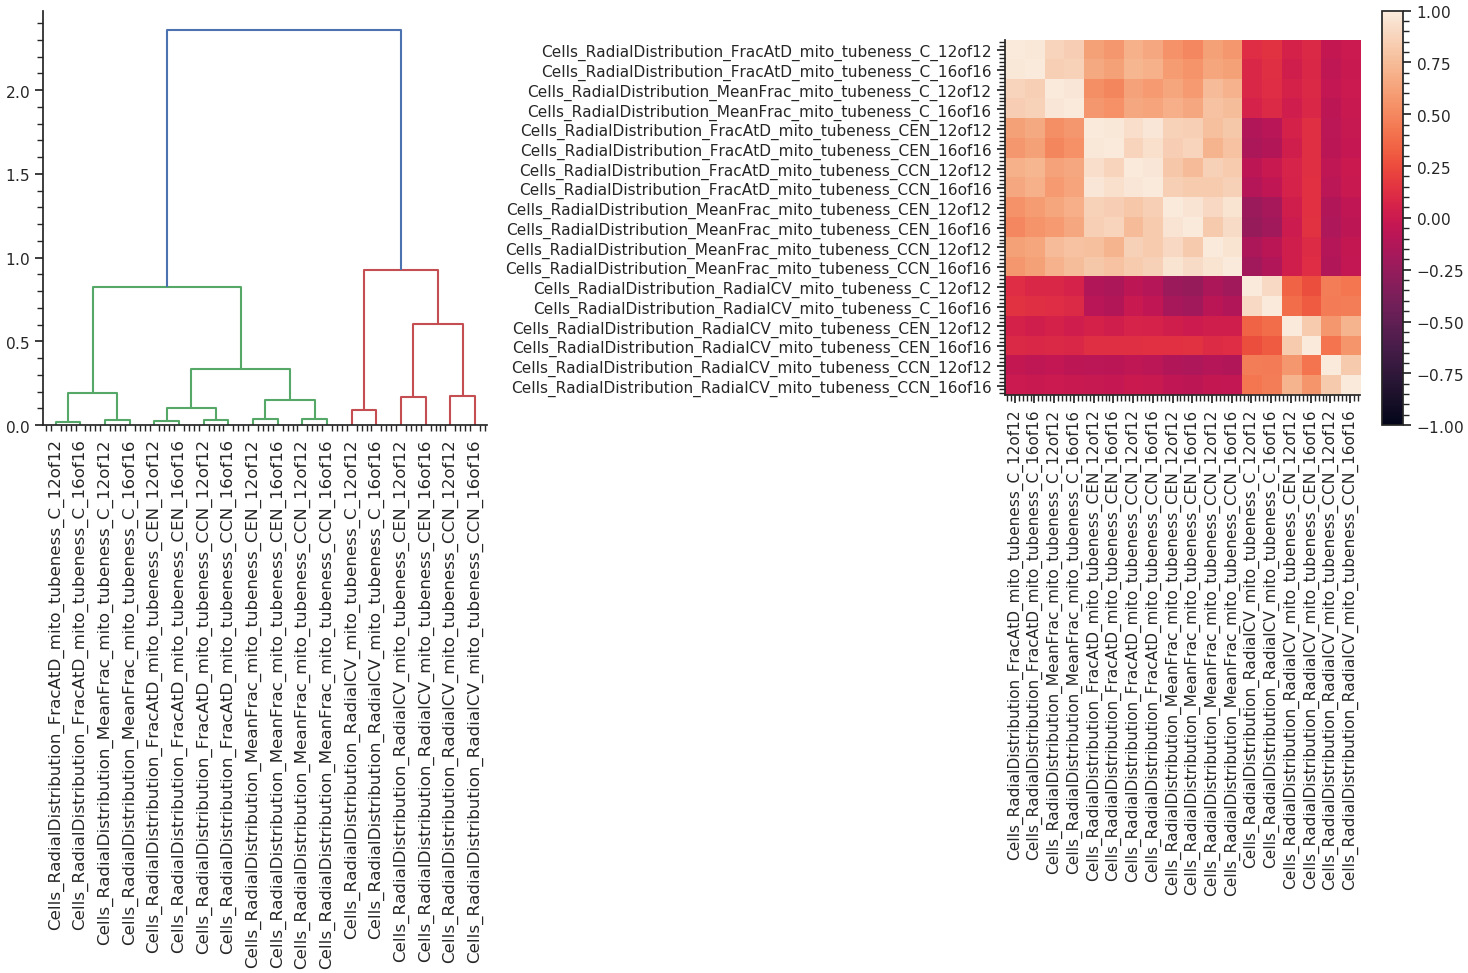

In [66]:
fs_mito_tubeness = df_1_scaled.columns[
        df_1_scaled.columns.str.contains("12of12|16of16")
    ].tolist()
# fs_mito_tubeness
dendf=check_feature_similarity_dendrogram(df_1_scaled, fs_mito_tubeness,(15, 10))

## Mito-Slope per categories of patients

0.0034
0.0043
0.013
0.24
0.13


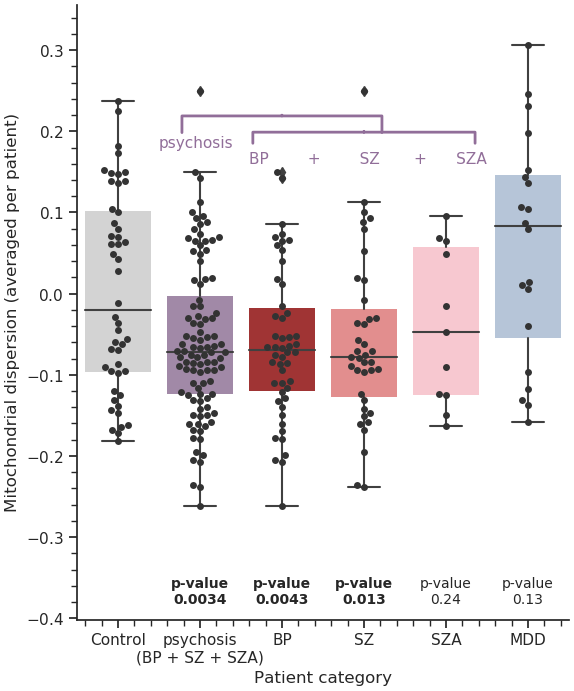

In [69]:
from utils import find_end_slope2
import scipy.stats as stats
plt.style.use(['science','no-latex','nature'])
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params,font_scale=1)

def round_sig(x, sig=2):
#     To round to n significant digits (non-zero digits)
    if x == 0:
        return 0
    return round(x, sig - int(np.floor(np.log10(abs(x)))) - 1)

targetFeature='slope'

# plt.rcParams['font.size'] = '10'
data_phs0 = df_1_avg_persub.groupby(['label','subject']).mean().reset_index()
data_phs_psych=data_phs0[data_phs0['label'].isin(["BP","SZ","SZA"])].copy()
data_phs_psych['label']='psychosis'
data_phs=pd.concat([data_phs0,data_phs_psych],ignore_index=True)

fig, axes = plt.subplots(1, 1, figsize=(6,7))
# mediumvioletred
orderC=["Control","psychosis","BP","SZ","SZA","MDD"]
# palette = ['lightsteelblue','#a484ac','firebrick','lightcoral','pink','lightgreen']
palette = ['lightgray','#a484ac','firebrick','lightcoral','pink','lightsteelblue']

sns.boxplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
sns.swarmplot(x="label", y=targetFeature, data=data_phs,order=orderC,ax=axes, color=".2")
############################
mi,ma=data_phs[targetFeature].describe()[['min','max']]
# data_phs.loc[data_phs['label']=='Control',targetFeature]

for i in range(len(orderC)):
    if orderC[i]!='Control':
        pval=round_sig(ttest_ind(data_phs.loc[data_phs['label']=='Control',targetFeature].values,\
                  data_phs.loc[data_phs['label']==orderC[i],targetFeature].values,equal_var=False).pvalue,2)
#         pval=np.round(ps_ttest_all_cats[(ps_ttest_all_cats['feature']==targetFeature) & \
#                                    (ps_ttest_all_cats['label']==orderC[i])]['p'].values[0],4)
    #     pvl = pvals[i]#p.get_width()
        print(pval)
        if pval<0.05:
            weight_f='bold'
        else:
            weight_f=None
        axes.annotate('p-value\n'+str(pval),xy=(i,mi-0.12),horizontalalignment='center',size='small',weight=weight_f)

axes.set_ylim([mi-0.14,ma+0.05]);    

ofset1=1
ofset2=1.04
axes.annotate('', xy=(3, 1.199-ofset1), xytext=(3, 1.20-ofset1), fontsize=4, \
              arrowprops=dict(arrowstyle='-[, widthB=20.0, lengthB=2',color='#916e99', lw=2.0))

axes.annotate('', xy=(2, 1.259-ofset2), xytext=(2, 1.26-ofset2), fontsize=4, \
              arrowprops=dict(arrowstyle='-[, widthB=18, lengthB=3',color='#916e99', lw=2.0))
axes.text(x=0.5,y=0.18,s='psychosis',color='#916e99',fontsize=11)
axes.text(x=1.6,y=0.16,s='BP        +        SZ       +      SZA',color='#916e99',fontsize=11)

axes.set(ylabel='Mitochondrial dispersion (averaged per patient)')

axes.set(xlabel='Patient category')
plt.tight_layout()

labels = [tick.get_text() for tick in axes.get_xticklabels()]
labels[1] = "psychosis\n(BP + SZ + SZA)"
axes.set_xticklabels(labels)
        
fig.savefig("../results/Figure4c.pdf", bbox_inches="tight")

## Mito-Slope per sub-categories of patients

/opt/tljh/user/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3584: RuntimeWarning: Degrees of freedom <= 0 for slice
  **kwargs)
/opt/tljh/user/lib/python3.7/site-packages/numpy/core/_methods.py:209: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


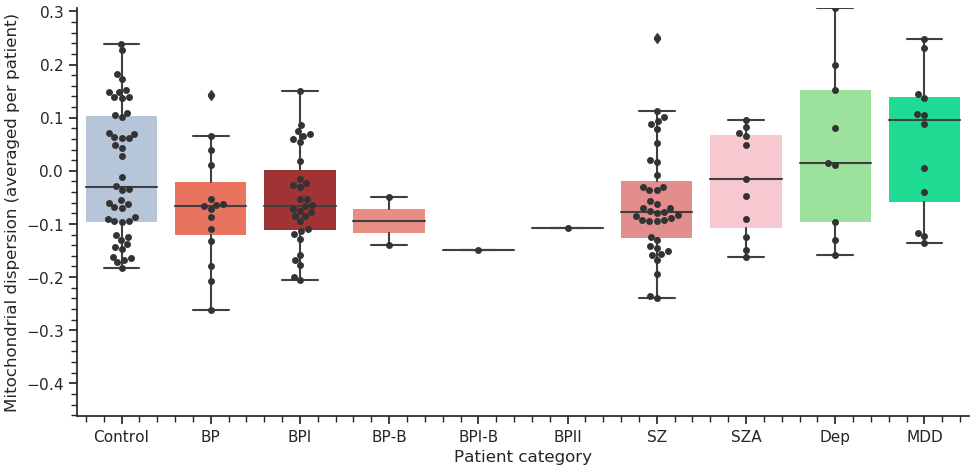

In [20]:
plt.style.use(['science','no-latex','nature'])
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params,font_scale=1)


disease_labels=pd.read_excel(home_path+"bucket/projects/2016_08_01_RadialMitochondriaDistribution_donna/\
workspace/metadata/patient_labels.xlsx")
disease_labels=disease_labels.rename(columns={"ID": "subject"})
disease_labels["subject"]=disease_labels["subject"].astype(str)


data_phs_collapsed=pd.merge(data_phs0,disease_labels,on=["subject"],how="left")
data_phs=pd.merge(data_phs0,disease_labels,on=["subject"],how="left")

orderC=['Control','BP', 'BPI','BP-B', 'BPI-B','BPII', 'SZ', 'SZA','Dep','MDD']

palette = ['lightsteelblue','tomato','firebrick','salmon','lightcoral','pink','lightcoral','pink','lightgreen','mediumspringgreen']

fig, axes = plt.subplots(1, 1, figsize=(10,5))

sns.boxplot(x="D1", y=targetFeature, data=data_phs_collapsed,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
sns.swarmplot(x="D1", y=targetFeature, data=data_phs_collapsed,order=orderC,ax=axes, color=".2")
############################
mi,ma=data_phs[targetFeature].describe()[['min','max']]
# data_phs.loc[data_phs['label']=='Control',targetFeature]


for i in range(len(orderC)):
    if orderC[i]!='Control':
        pvl=ttest_ind(data_phs.loc[data_phs['D1']=='Control',targetFeature].values,\
                  data_phs.loc[data_phs['D1']==orderC[i],targetFeature].values,equal_var=False).pvalue
    
        if 0:
            print(pvl)
            if pvl<0.05:
                if pvl<0.0001:
                    pval=pvl
                else:
                    pval=np.round(pvl,4)
                weight_f='bold'
                axes.annotate('p-value\n'+str(pval),xy=(i,mi-0.17),horizontalalignment='center',size='small',weight=weight_f)
            else:
                pval=np.round(pvl,2)
                weight_f=None
#         axes.annotate('p-value\n'+str(pval),xy=(i,mi-0.17),horizontalalignment='center',size='small',weight=weight_f)
        
axes.set_ylim([mi-0.2,ma]);       


axes.set(ylabel='Mitochondrial dispersion (averaged per patient)')
axes.set(xlabel='Patient category')
plt.tight_layout()

## Figure 4.b

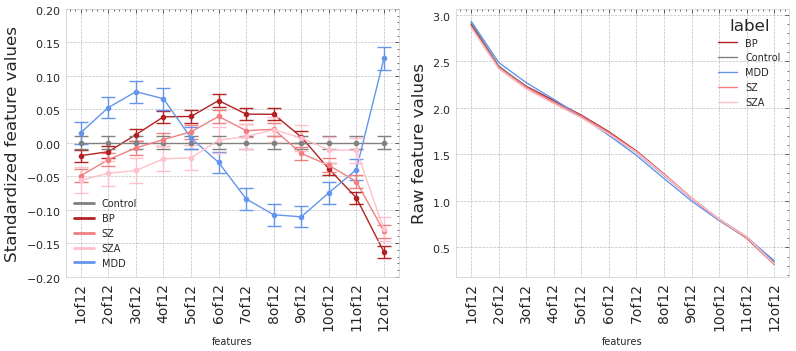

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
plt.style.use(['science','no-latex','nature'])
labels = ["Control","BP","SZ","SZA","MDD"]

colors = ['gray','firebrick','lightcoral','pink','cornflowerblue']
color_dict = dict(zip(labels, colors)) 

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
fig.subplots_adjust(wspace=0.5, bottom=0.5)
sns.set_style("whitegrid")

means = df_1_scaled.groupby("label").mean()[target_columns]

means=means-means.loc['Control']

std_dev = df_1_scaled.groupby("label").std()[target_columns]
counts = df_1_scaled.groupby("label").count()[target_columns]
standard_errors = std_dev / np.sqrt(counts)

# for the scaled data
scaled_data = means.T.reset_index().melt(id_vars='index', var_name='label')
scaled_data.columns = ['features', 'label', 'mean']

scaled_data['se'] = (std_dev / np.sqrt(counts)).T.reset_index().melt(id_vars='index').value

scaled_data['features'] = scaled_data['features'].apply(lambda x: x.split('_')[-1])

for label, group in scaled_data.groupby('label'):
    sns.lineplot(x=group['features'], y=group['mean'], color=color_dict[label], ax=ax[0])  # Add this line
    ax[0].errorbar(group['features'], group['mean'], yerr=group['se'], 
                   fmt='o', capsize=5, label=label, color=color_dict[label])

ax[0].set_ylabel('Standardized feature values', fontsize=12)
# ax[0].legend().set_visible(False)


legend_handles = [Line2D([0], [0], color=color_dict[label], lw=2, label=label) for label in labels]
ax[0].legend(handles=legend_handles, title="", loc="lower left")
ax[0].set_ylim([-.2,.2]);

raw_data = df_1.groupby("label").mean()[target_columns].T.reset_index().melt(id_vars='index', var_name='label')
raw_data.columns = ['features', 'label', 'mean']
raw_data['features'] = raw_data['features'].apply(lambda x: x.split('_')[-1])

sns.lineplot(data=raw_data, x='features', y='mean', hue='label', 
             palette=color_dict, ax=ax[1], legend='brief')
ax[1].set_ylabel('Raw feature values', fontsize=12)

# rotate x-axis labels and adjust the size
for axes in ax:
    axes.tick_params(axis='x', labelrotation=90, labelsize=10)
    axes.tick_params(axis='y', labelsize=8)
    axes.grid(True, linestyle='--', which='major', color='gray', alpha=.5)

plt.tight_layout()

# Save only the first subplot (ax[0]) as an SVG file
extent = ax[0].get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig("../results/Figure4b.pdf", format="pdf", bbox_inches=extent)


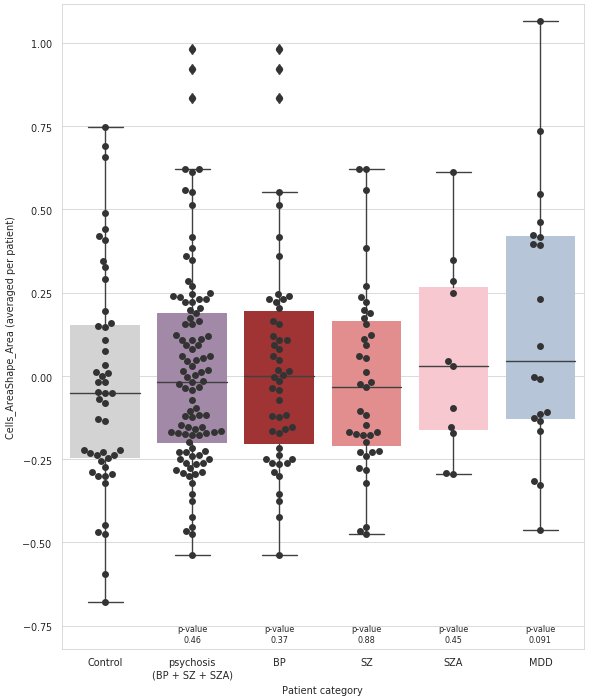

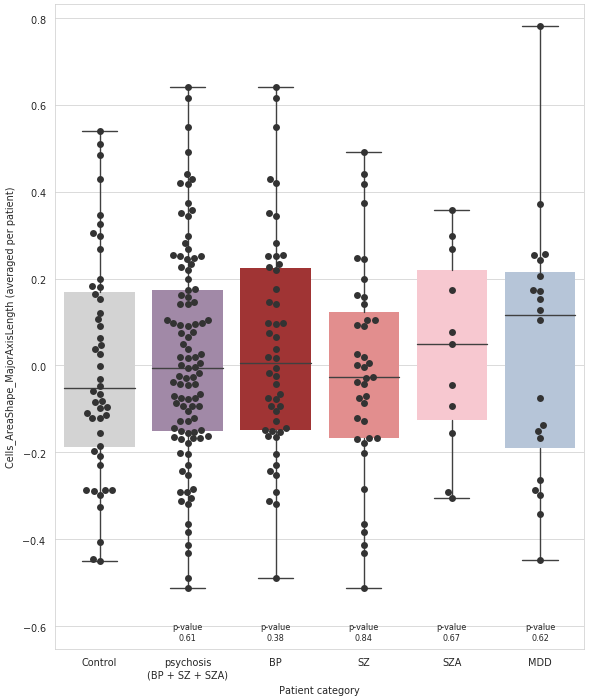

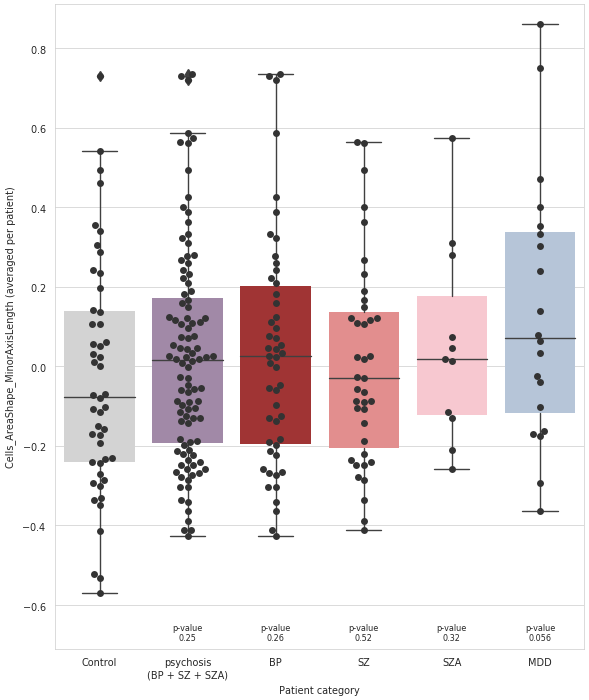

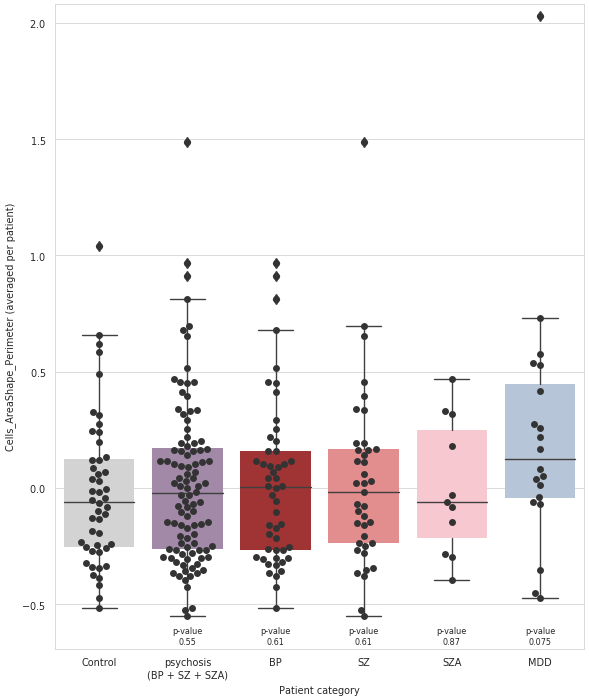

In [74]:
for tar in ['Cells_AreaShape_Area','Cells_AreaShape_MajorAxisLength','Cells_AreaShape_MinorAxisLength','Cells_AreaShape_Perimeter']:

    fig, axes = plt.subplots(1, 1, figsize=(6,7))
    # mediumvioletred
    orderC=["Control","psychosis","BP","SZ","SZA","MDD"]
    # palette = ['lightsteelblue','#a484ac','firebrick','lightcoral','pink','lightgreen']
    palette = ['lightgray','#a484ac','firebrick','lightcoral','pink','lightsteelblue']

    sns.boxplot(x="label", y=tar, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
    sns.swarmplot(x="label", y=tar, data=data_phs,order=orderC,ax=axes, color=".2")
    ############################
    mi,ma=data_phs[tar].describe()[['min','max']]
    # data_phs.loc[data_phs['label']=='Control',tar]

    for i in range(len(orderC)):
        if orderC[i]!='Control':
            pval=round_sig(ttest_ind(data_phs.loc[data_phs['label']=='Control',tar].values,\
                      data_phs.loc[data_phs['label']==orderC[i],tar].values,equal_var=False).pvalue,2)
    #         pval=np.round(ps_ttest_all_cats[(ps_ttest_all_cats['feature']==tar) & \
    #                                    (ps_ttest_all_cats['label']==orderC[i])]['p'].values[0],4)
        #     pvl = pvals[i]#p.get_width()
            # print(pval)
            if pval<0.05:
                weight_f='bold';
            else:
                weight_f=None;
            axes.annotate('p-value\n'+str(pval),xy=(i,mi-0.12),horizontalalignment='center',size='small',weight=weight_f);

    axes.set_ylim([mi-0.14,ma+0.05]);    

#     ofset1=1
#     ofset2=1.04
#     axes.annotate('', xy=(3, 1.199-ofset1), xytext=(3, 1.20-ofset1), fontsize=4, \
#                   arrowprops=dict(arrowstyle='-[, widthB=20.0, lengthB=2',color='#916e99', lw=2.0))

#     axes.annotate('', xy=(2, 1.259-ofset2), xytext=(2, 1.26-ofset2), fontsize=4, \
#                   arrowprops=dict(arrowstyle='-[, widthB=18, lengthB=3',color='#916e99', lw=2.0))
#     axes.text(x=0.5,y=0.18,s='psychosis',color='#916e99',fontsize=11)
#     axes.text(x=1.6,y=0.16,s='BP        +        SZ       +      SZA',color='#916e99',fontsize=11)

    axes.set(ylabel=tar+' (averaged per patient)');

    axes.set(xlabel='Patient category');
    plt.tight_layout();

    labels = [tick.get_text() for tick in axes.get_xticklabels()];
    labels[1] = "psychosis\n(BP + SZ + SZA)"
    axes.set_xticklabels(labels);

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: all numeric columns except the target
y_col = "slope"
# feature_cols =[c for c in df.select_dtypes(include="number").columns if c != y_col]
feature_cols = ['Cells_AreaShape_Area','Cells_AreaShape_MajorAxisLength','Cells_AreaShape_MinorAxisLength','Cells_AreaShape_Perimeter'];
# Compute correlation of each feature with target
corr = df_1_avg_persub[feature_cols].corrwith(df_1_avg_persub[y_col])
corr
# # Make a scatter plot
# fig, ax = plt.subplots(figsize=(10, 4))
# ax.scatter(range(len(corr)), corr)

# ax.set_xticks(range(len(corr)))
# ax.set_xticklabels(corr.index, rotation=90)
# ax.axhline(0, linestyle="--", linewidth=1)  # zero line

Cells_AreaShape_Area               0.284611
Cells_AreaShape_MajorAxisLength    0.166055
Cells_AreaShape_MinorAxisLength    0.297302
Cells_AreaShape_Perimeter          0.393736
dtype: float64

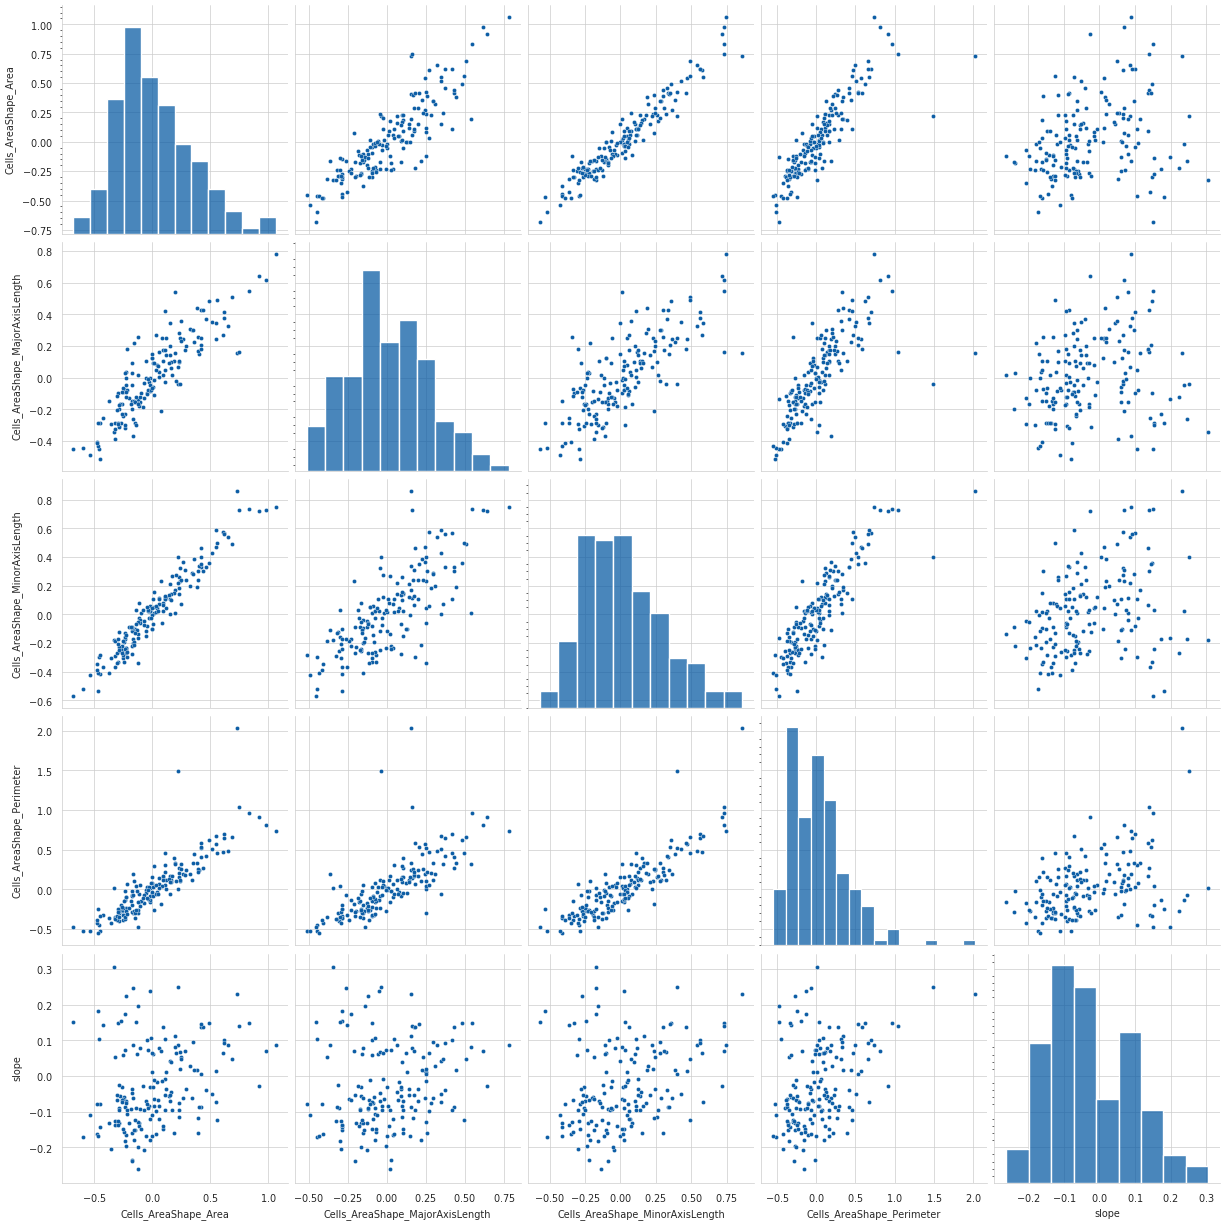

In [76]:
# df_1_avg_persub[feature_cols]

import seaborn as sns
import matplotlib.pyplot as plt



sns.pairplot(df_1_avg_persub[feature_cols+['slope']])
plt.show()

## Orthogonal features

In [92]:
from sklearn.feature_selection import mutual_info_classif

X,y=df_1_avg_persub.loc[:,cp_features_analysis].values,sp.LabelEncoder().fit_transform(df_1_avg_persub['label'].values);
mi = mutual_info_classif(X, y)
mi_df_all_labels = pd.DataFrame({'Feature': cp_features_analysis, 'Mutual_Info': mi}).sort_values('Mutual_Info', ascending=False)

fq_all_ds=pd.read_csv(rootDir + "/workspace/results/jump_fq/fq_csvs/fq_all_datasets.csv")

fq_all_ds2=fq_all_ds[~fq_all_ds[['jump_orf', 'jump_crispr',\
                'jump_compound', 'CDRP', 'taorf']].isna().any(axis=1)].reset_index(drop=True)

fq_all_ds3=fq_all_ds2[fq_all_ds2["median_across_ds"]<fq_all_ds["median_across_ds"].quantile(q=.80)].reset_index(drop=True)


low_mi_features0=mi_df_all_labels[mi_df_all_labels["Mutual_Info"]<0.001].Feature.tolist()

low_mi_features=list(set(low_mi_features0)  &  set(fq_all_ds3["features"]))

print(len(low_mi_features))

df_1_scaled_median2=df_1_avg_persub.copy()
# df_1_scaled_median2.columns=df_1_scaled_median2.columns.str.replace('Actin', 'AGP', regex=True)

low_mi_cc_to_slope=df_1_scaled_median2[low_mi_features].corrwith(df_1_scaled_median2['slope']).abs().sort_values().reset_index()\
.rename(columns={'index':'features',0:'abs_cc'})
low_mi_low_cc_to_slope=low_mi_cc_to_slope[low_mi_cc_to_slope["abs_cc"]<0.3].features.tolist()
print(len(low_mi_low_cc_to_slope))
similar_fs_2remove_2=find_correlation(df_1_scaled_median2[low_mi_low_cc_to_slope],\
                                                 threshold=0.8,remove_negative=True)

low_mi_low_cc_to_slope2=list(set(low_mi_low_cc_to_slope) - set(similar_fs_2remove_2))
print(len(low_mi_low_cc_to_slope2))
final_features_to_use_for_VS=[l for l in low_mi_low_cc_to_slope2 if ('of16' not in l) and ('of12' not in l)]

146
81
26
